In [1]:
# ============================================================
# SECTION 1: IMPORT LIBRARIES
# ============================================================
# Think of libraries as toolboxes. Each one gives us
# specific tools we need for different tasks.
# ============================================================

# --- DATA HANDLING ---
import pandas as pd          # Lets us load and work with data in tables (like Excel in Python)
import numpy as np           # Lets us do fast math and handle arrays of numbers

# --- VISUALIZATION (Charts & Plots) ---
import matplotlib.pyplot as plt   # The base plotting library in Python
import seaborn as sns             # Built on top of matplotlib — makes prettier charts with less code

# --- MACHINE LEARNING MODELS ---
from sklearn.linear_model import LogisticRegression       # Model 1: Logistic Regression
from sklearn.tree import DecisionTreeClassifier           # Model 2: Decision Tree
from sklearn.ensemble import RandomForestClassifier       # Model 3: Random Forest
from sklearn.ensemble import GradientBoostingClassifier   # Model 4: Gradient Boosting
from sklearn.svm import SVC                               # Model 5: Support Vector Classifier (SVC)
from xgboost import XGBClassifier                         # Model 6: XGBoost

# --- PREPROCESSING (Preparing data for models) ---
from sklearn.model_selection import train_test_split      # Splits data into training and test sets
from sklearn.preprocessing import LabelEncoder            # Converts text categories to numbers
from sklearn.preprocessing import StandardScaler          # Scales numbers to the same range

# --- HANDLING CLASS IMBALANCE ---
# SMOTE = Synthetic Minority Oversampling Technique
# It creates fake examples of the minority class (defaulters) so models don't ignore them
from imblearn.over_sampling import SMOTE

# --- MODEL EVALUATION (Measuring how good our models are) ---
from sklearn.metrics import (
    accuracy_score,           # % of correct predictions
    precision_score,          # Of all predicted defaults, how many were real?
    recall_score,             # Of all real defaults, how many did we catch?
    f1_score,                 # Balance between precision and recall
    roc_auc_score,            # How well the model separates defaulters from non-defaulters (0.5=random, 1.0=perfect)
    confusion_matrix,         # Table showing correct vs wrong predictions
    classification_report,    # Full breakdown of precision, recall, f1 per class
    RocCurveDisplay           # Plots the ROC curve visually
)

# --- SHAP (Explainability — shows WHY the model made a prediction) ---
import shap

# --- WARNINGS ---
import warnings
warnings.filterwarnings('ignore')   # Suppresses non-critical warning messages so output is clean

# --- DISPLAY SETTINGS ---
pd.set_option('display.max_columns', None)   # Show all columns when printing a dataframe
pd.set_option('display.float_format', '{:.2f}'.format)  # Round floats to 2 decimal places

# Set a consistent visual style for all our plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)   # Default chart size: width=12, height=6

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


C:\Users\Abigael Mwangi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# SECTION 1b: LOCATE THE DATASET (Local Version)
# ============================================================
# Scans the current working directory for any CSV files.
# On Kaggle this used /kaggle/input/; locally we scan the
# folder where this notebook lives.
# ============================================================

import os

print("=" * 60)
print("SCANNING FOR CSV FILES IN PROJECT DIRECTORY")
print("=" * 60)

for root, dirs, files in os.walk('.'):
    # Skip hidden folders like .ipynb_checkpoints
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    for file in files:
        if file.endswith('.csv'):
            full_path = os.path.join(root, file)
            print(full_path)

print("\n" + "=" * 60)
print("Use the path above in Section 2.")
print("=" * 60)


SCANNING FOR CSV FILES IN PROJECT DIRECTORY
.\credit_risk_dataset.csv

Use the path above in Section 2.


In [3]:
# ============================================================
# SECTION 2: LOAD & INSPECT THE DATA
# ============================================================
# Before doing anything, we need to understand:
#   - What columns (features) exist?
#   - How many rows do we have?
#   - What data types are present?
#   - Are there missing values?
#   - What does our target column look like?
# ============================================================

# --- STEP 2.1: Load the CSV file into a DataFrame ---
# A DataFrame is like a spreadsheet — rows = records, columns = features
# Kaggle stores uploaded datasets in /kaggle/input/
df = pd.read_csv('credit_risk_dataset.csv')

print("=" * 55)
print("STEP 2.1 — Dataset Loaded")
print("=" * 55)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
# Shape tells you: (number of records, number of features)


# --- STEP 2.2: Preview the first 5 rows ---
# This gives you a feel for what the data looks like
print("=" * 55)
print("STEP 2.2 — First 5 Rows (Head)")
print("=" * 55)
display(df.head())


# --- STEP 2.3: Column names and data types ---
# 'object' means text/string. 'int64' or 'float64' means numbers.
print("=" * 55)
print("STEP 2.3 — Column Names & Data Types")
print("=" * 55)
print(df.dtypes)


# --- STEP 2.4: Summary statistics ---
# Shows min, max, mean, standard deviation, quartiles for numeric columns
# This helps spot outliers (e.g., age = 144 is impossible → outlier)
print("\n")
print("=" * 55)
print("STEP 2.4 — Summary Statistics")
print("=" * 55)
display(df.describe())


# --- STEP 2.5: Check for missing values ---
# Missing values can crash models or produce wrong results if not handled
print("=" * 55)
print("STEP 2.5 — Missing Values per Column")
print("=" * 55)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100   # As a percentage

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])   # Only show columns with missing values


# --- STEP 2.6: Check the TARGET column distribution ---
# Our target is 'loan_status':
#   0 = Loan was repaid (Non-default)
#   1 = Borrower defaulted (Default)
# This tells us if the data is IMBALANCED (many more 0s than 1s — very common in credit data)
print("\n")
print("=" * 55)
print("STEP 2.6 — Target Column: loan_status")
print("=" * 55)
counts = df['loan_status'].value_counts()
pcts = df['loan_status'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Count': counts,
    'Percentage': pcts
})
print(target_summary)
print("\n⚠️  If one class is much larger than the other, the data is IMBALANCED.")
print("    We will fix this in Section 5 using SMOTE.")

STEP 2.1 — Dataset Loaded
Shape: 32581 rows × 12 columns

STEP 2.2 — First 5 Rows (Head)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.00,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.00,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.00,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.00,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.00,MEDICAL,C,35000,14.27,1,0.55,Y,4


STEP 2.3 — Column Names & Data Types
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object


STEP 2.4 — Summary Statistics


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,31686.00,32581.00,29465.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.79,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.14,6322.09,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


STEP 2.5 — Missing Values per Column
                   Missing Count  Missing %
loan_int_rate               3116       9.56
person_emp_length            895       2.75


STEP 2.6 — Target Column: loan_status
             Count  Percentage
loan_status                   
0            25473       78.18
1             7108       21.82

⚠️  If one class is much larger than the other, the data is IMBALANCED.
    We will fix this in Section 5 using SMOTE.


STEP 3.1 — Class Distribution (Target Variable)


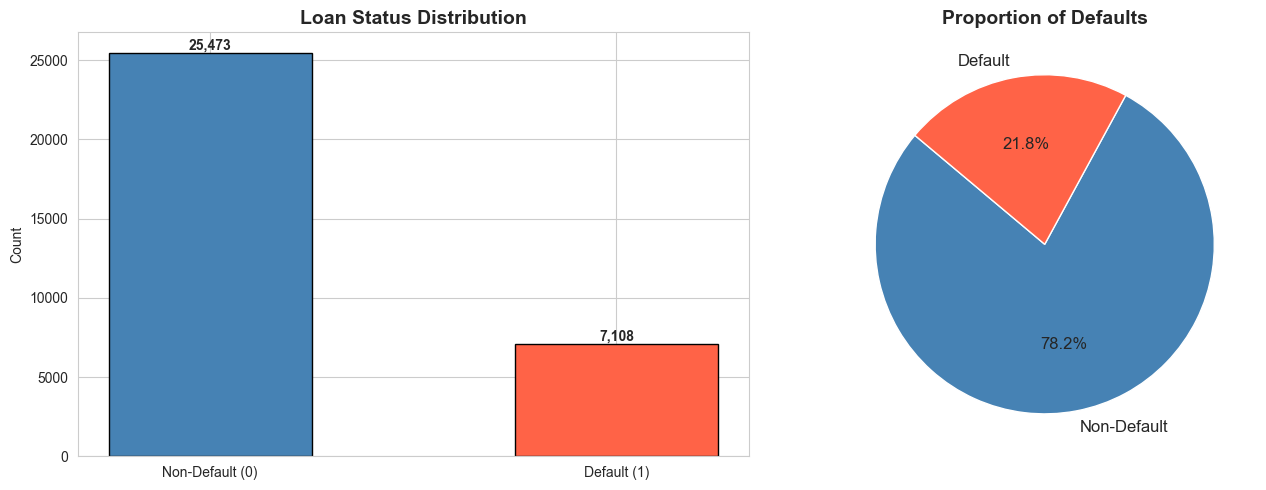

💡 If defaults are a small minority, models will be biased — we fix this with SMOTE later.

STEP 3.2 — Numeric Feature Distributions by Loan Status


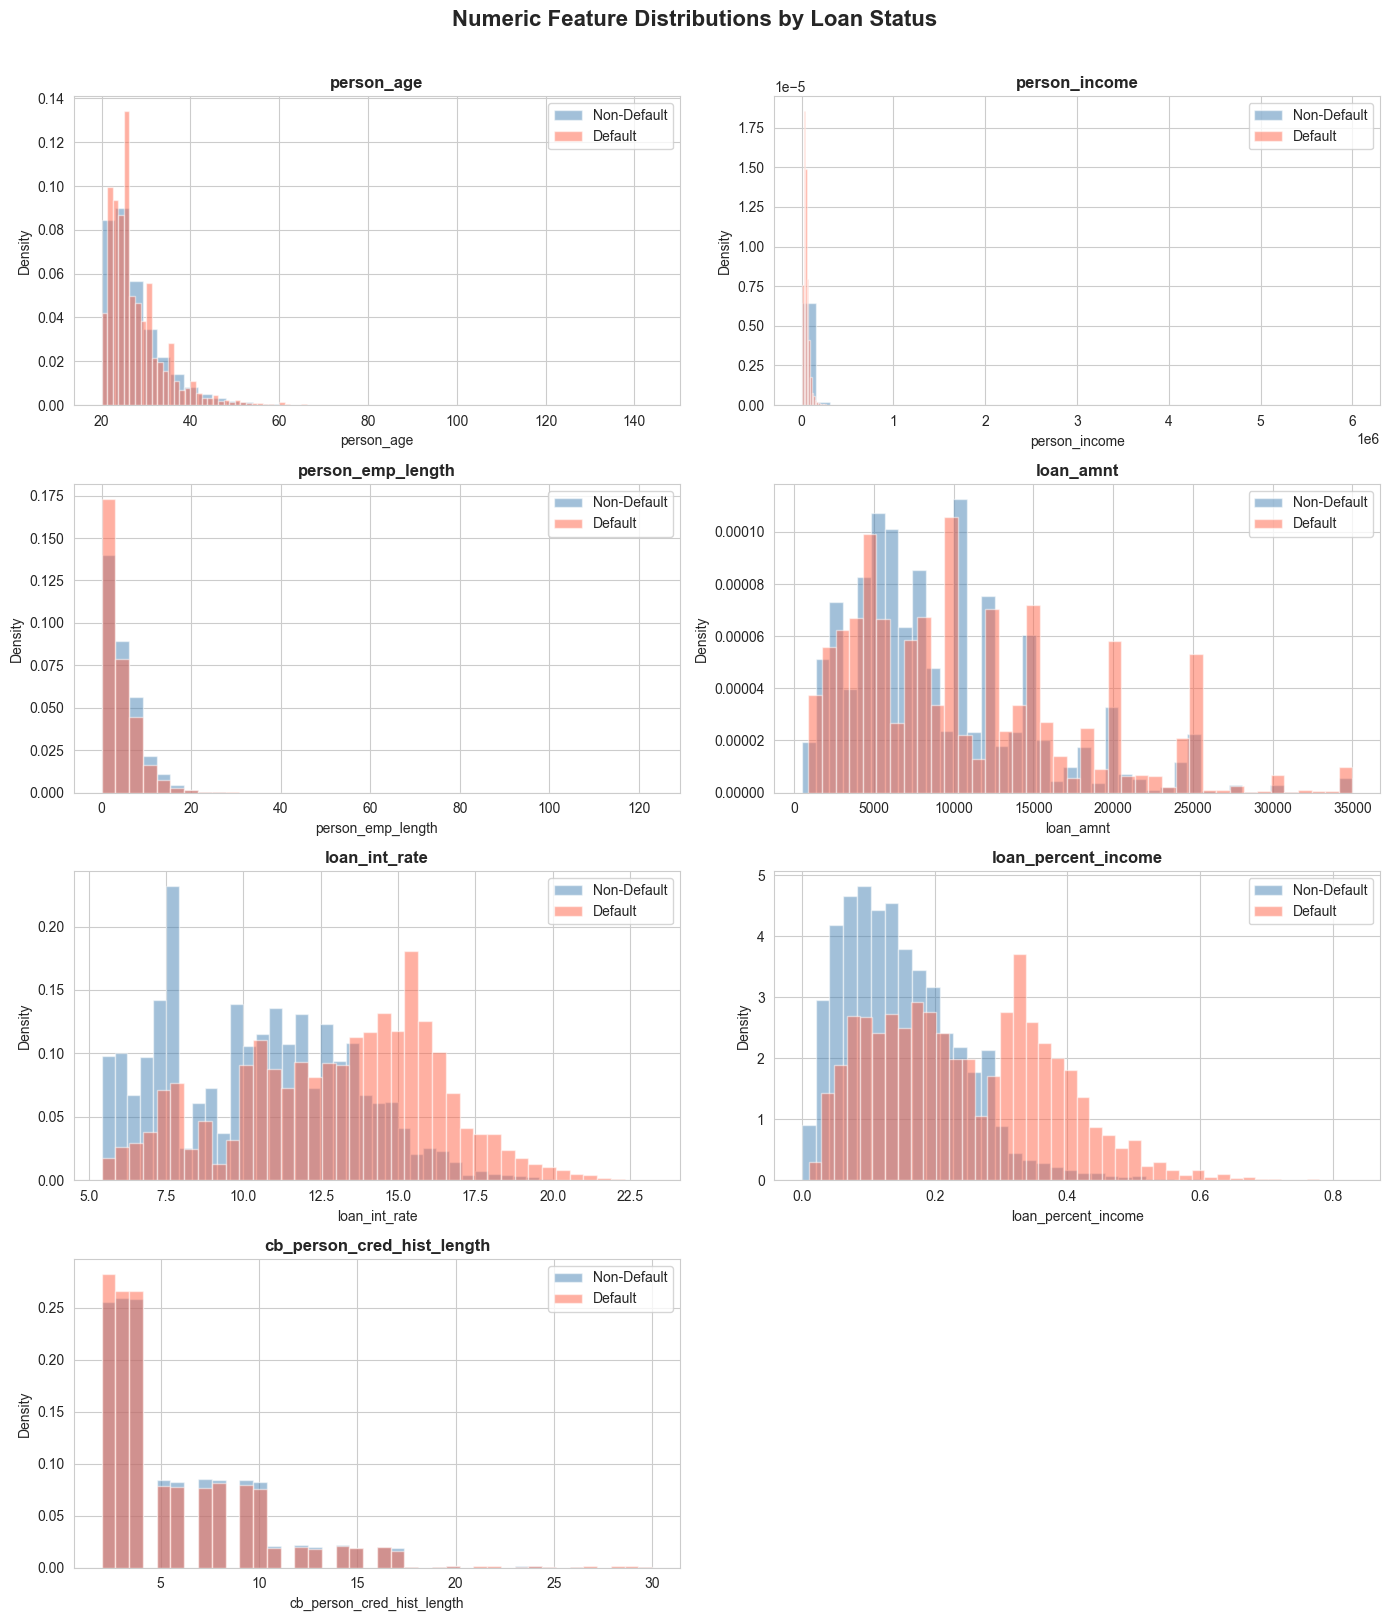

💡 If the two curves are far apart, that feature is a strong predictor of default.

STEP 3.3 — Categorical Features vs Loan Status


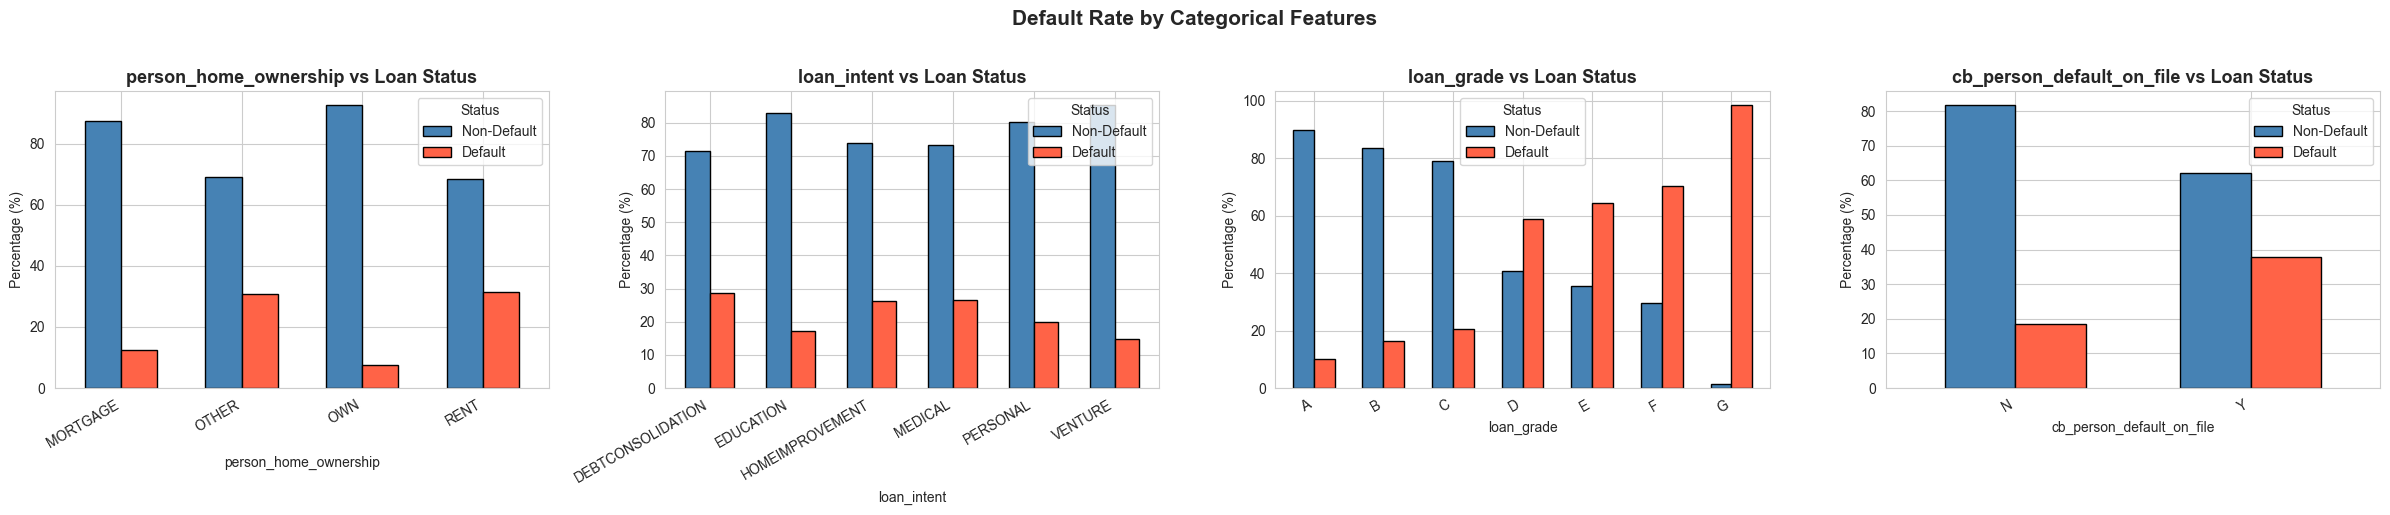

💡 Categories with higher red bars = higher default rates.

STEP 3.4 — Correlation Heatmap


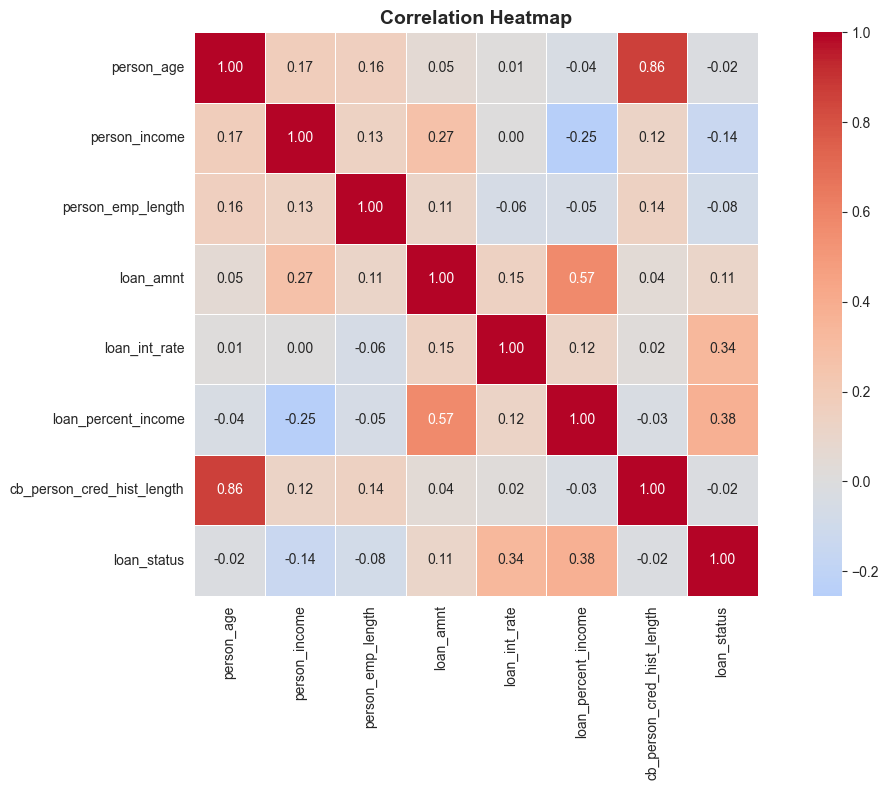

💡 Focus on the 'loan_status' row/column — high absolute values = important features.

STEP 3.5 — Box Plots to Detect Outliers


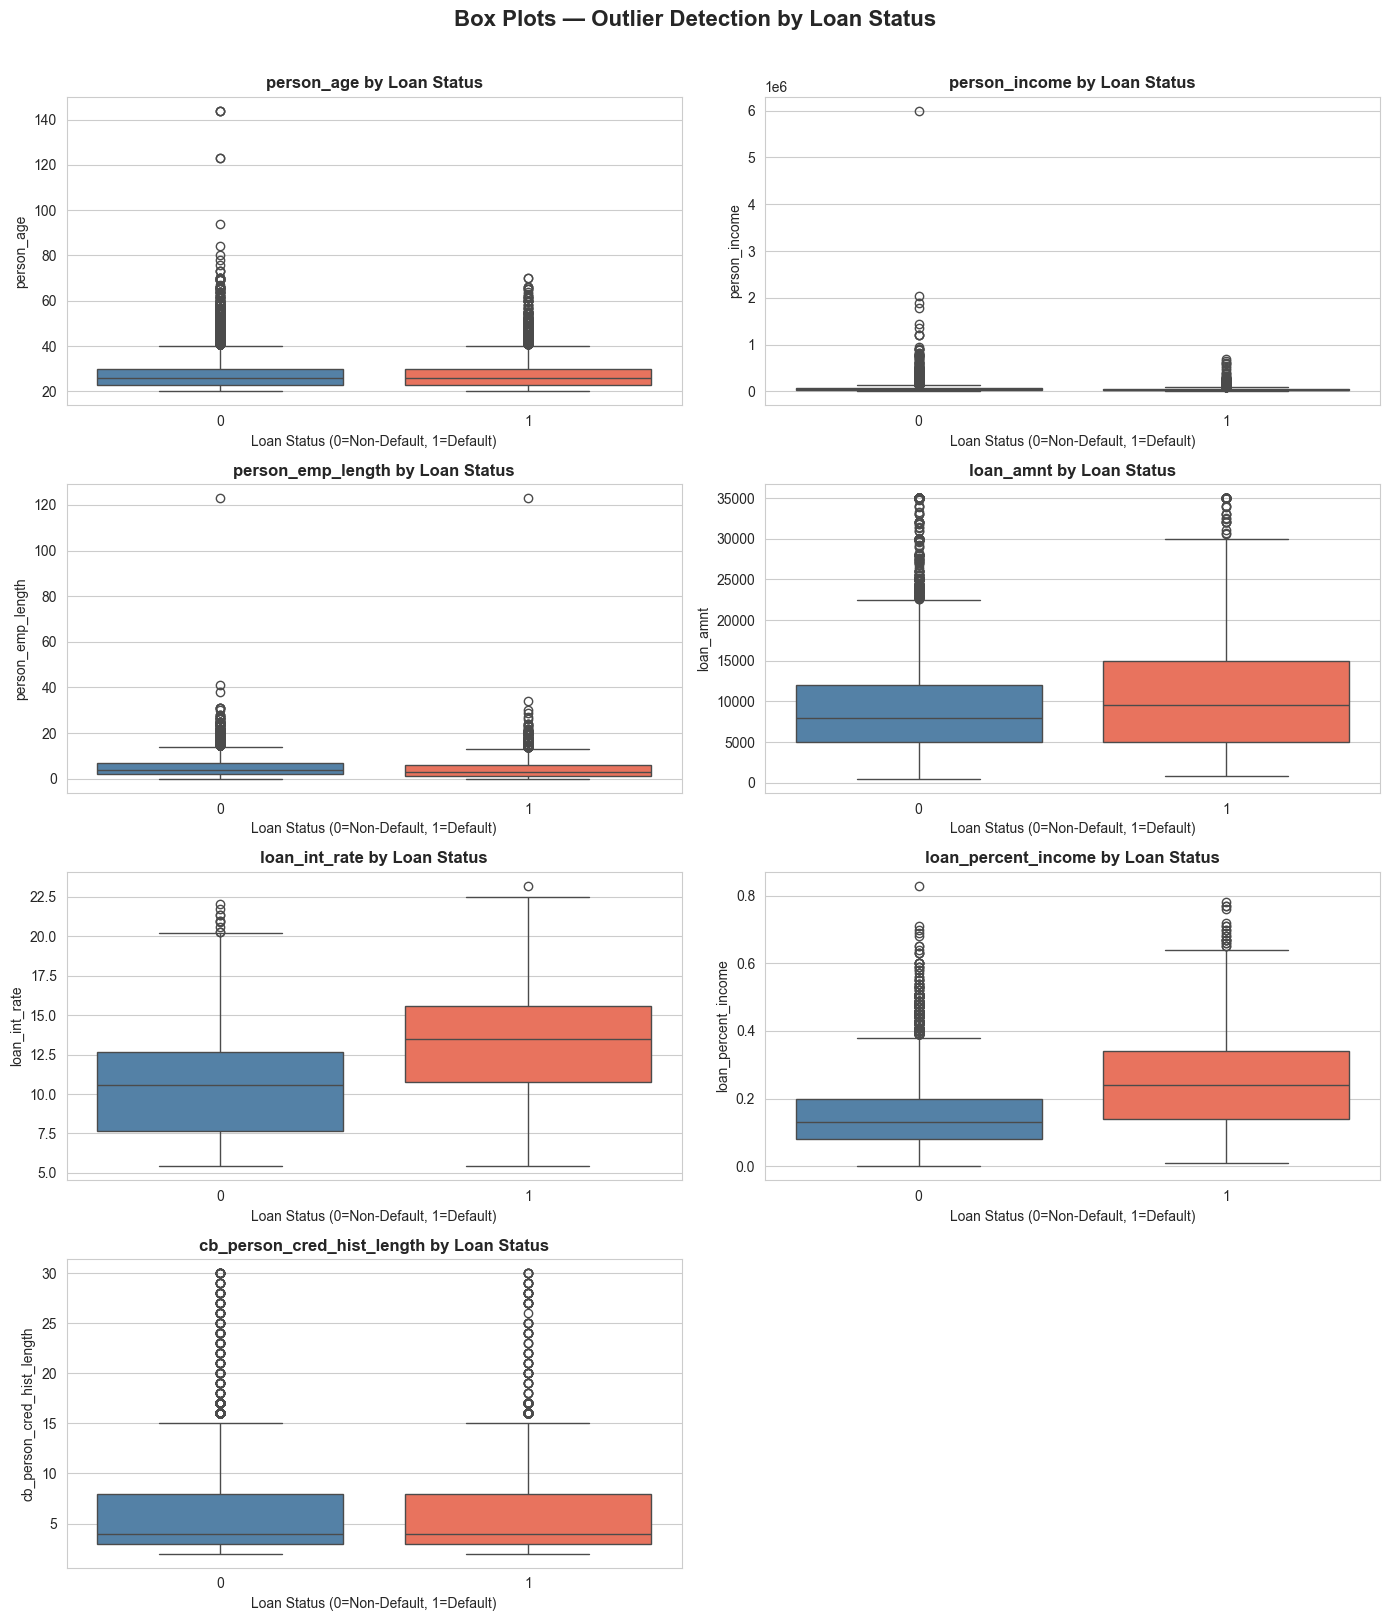

💡 Dots far from the boxes are outliers. Extreme outliers can mislead models.

✅ EDA Complete! You now understand your data visually.
   Move to Section 4 to clean and prepare the data for modeling.


In [4]:
# ============================================================
# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
# EDA = Looking at your data visually and statistically
# to understand patterns BEFORE building any models.
#
# Good EDA answers:
#   - Which features are related to default?
#   - Are there outliers that could hurt our models?
#   - How are numeric features distributed?
#   - What do categorical features look like?
# ============================================================


# --- STEP 3.1: Class Imbalance Bar Chart ---
# Visualizing how skewed the target column is
print("STEP 3.1 — Class Distribution (Target Variable)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['loan_status'].value_counts()
axes[0].bar(['Non-Default (0)', 'Default (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
axes[0].set_title('Loan Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Non-Default', 'Default'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%',
            startangle=140, textprops={'fontsize': 12})
axes[1].set_title('Proportion of Defaults', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 If defaults are a small minority, models will be biased — we fix this with SMOTE later.\n")


# --- STEP 3.2: Distribution of Numeric Features ---
# A histogram shows how values are spread.
# A KDE (Kernel Density Estimate) is a smooth curve version of the histogram.
# We split by loan_status to see if defaulters differ from non-defaulters.
print("STEP 3.2 — Numeric Feature Distributions by Loan Status")

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'loan_status']  # Exclude target

n_cols = 2
n_rows = (len(numeric_cols) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Plot one KDE line for each class (0 and 1)
    for status, color, label in zip([0, 1], ['steelblue', 'tomato'], ['Non-Default', 'Default']):
        subset = df[df['loan_status'] == status][col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.5, color=color, label=label, density=True)
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions by Loan Status', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 If the two curves are far apart, that feature is a strong predictor of default.\n")


# --- STEP 3.3: Categorical Feature Analysis ---
# For text columns (like loan_intent, home_ownership), we count how
# many defaulters vs non-defaulters fall into each category.
print("STEP 3.3 — Categorical Features vs Loan Status")

cat_cols = df.select_dtypes(include='object').columns.tolist()

fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 5))
if len(cat_cols) == 1:
    axes = [axes]

for i, col in enumerate(cat_cols):
    # Normalize=True gives us the proportion within each category (not raw counts)
    crosstab = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
    crosstab.columns = ['Non-Default', 'Default']
    crosstab.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'],
                  edgecolor='black', width=0.6)
    axes[i].set_title(f'{col} vs Loan Status', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].legend(title='Status')

plt.suptitle('Default Rate by Categorical Features', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Categories with higher red bars = higher default rates.\n")


# --- STEP 3.4: Correlation Heatmap (Numeric Features Only) ---
# Correlation = How strongly two variables move together.
# Range: -1 (opposite direction) to +1 (same direction), 0 = no relationship.
# We want to see which features correlate with loan_status.
print("STEP 3.4 — Correlation Heatmap")

plt.figure(figsize=(12, 8))
corr_matrix = df[numeric_cols + ['loan_status']].corr()

sns.heatmap(
    corr_matrix,
    annot=True,          # Show the correlation numbers inside each cell
    fmt='.2f',           # Round to 2 decimal places
    cmap='coolwarm',     # Red = positive correlation, Blue = negative
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Focus on the 'loan_status' row/column — high absolute values = important features.\n")


# --- STEP 3.5: Outlier Detection with Box Plots ---
# A box plot shows:
#   - The box = middle 50% of data
#   - The line inside = median
#   - Dots outside the whiskers = OUTLIERS
print("STEP 3.5 — Box Plots to Detect Outliers")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='loan_status', y=col,
                palette={'0': 'steelblue', '1': 'tomato'}, ax=axes[i])
    axes[i].set_title(f'{col} by Loan Status', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Loan Status (0=Non-Default, 1=Default)')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots — Outlier Detection by Loan Status', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Dots far from the boxes are outliers. Extreme outliers can mislead models.\n")

print("✅ EDA Complete! You now understand your data visually.")
print("   Move to Section 4 to clean and prepare the data for modeling.")

In [5]:
# ============================================================
# SECTION 4: DATA PREPROCESSING & CLEANING
# ============================================================
# Raw data is almost never model-ready. We need to:
#   4.1 — Cap impossible outliers (age 144, emp_length 123)
#   4.2 — Fill missing values (loan_int_rate, person_emp_length)
#   4.3 — Encode categorical columns → numbers
#   4.4 — Train / Test split
# ============================================================


# --- STEP 4.1: Cap Impossible Outliers ---
# From EDA we saw: max age = 144, max emp_length = 123.
# These are data entry errors. We cap them at realistic domain limits.
# WHY cap instead of delete? Capping keeps all rows, deleting loses data.

print("=" * 55)
print("STEP 4.1 — Capping Impossible Outliers")
print("=" * 55)

df_clean = df.copy()   # Always work on a copy; keep the original intact

# Domain rule: no person is 100+ years old in a loan dataset
df_clean['person_age'] = df_clean['person_age'].clip(upper=75)

# Domain rule: no one has 100+ years of employment
df_clean['person_emp_length'] = df_clean['person_emp_length'].clip(upper=60)

print(f"person_age max after capping:       {df_clean['person_age'].max()}")
print(f"person_emp_length max after capping: {df_clean['person_emp_length'].max()}")
print("✅ Outliers capped.\n")


# --- STEP 4.2: Fill Missing Values ---
# We saw two columns had NaN values:
#   loan_int_rate     → 9.56% missing
#   person_emp_length → 2.75% missing
#
# Strategy: fill with the MEDIAN (not mean) because both columns
# have outliers that would skew the mean.

print("=" * 55)
print("STEP 4.2 — Filling Missing Values (Median Imputation)")
print("=" * 55)

for col in ['loan_int_rate', 'person_emp_length']:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"  {col}: filled {df[col].isnull().sum()} NaNs with median = {median_val:.2f}")

print(f"\nMissing values remaining: {df_clean.isnull().sum().sum()}")
print("✅ No more missing values.\n")


# --- STEP 4.3: Encode Categorical Columns ---
# Machine learning models only understand numbers, not text like 'RENT' or 'MEDICAL'.
# We use two strategies:
#
#   a) Label Encoding — for columns with a natural order (ordinal)
#      e.g., loan_grade: A > B > C > D > E > F > G  (A is best credit grade)
#
#   b) One-Hot Encoding (get_dummies) — for columns with no order (nominal)
#      e.g., loan_intent: EDUCATION, MEDICAL, PERSONAL … no natural ranking
#
# cb_person_default_on_file is Y/N → simple map: Y=1, N=0

print("=" * 55)
print("STEP 4.3 — Encoding Categorical Columns")
print("=" * 55)

# a) Ordinal encoding — loan_grade (A=0, B=1, … G=6 → but A is BEST so we invert)
grade_order = {'A': 6, 'B': 5, 'C': 4, 'D': 3, 'E': 2, 'F': 1, 'G': 0}
df_clean['loan_grade'] = df_clean['loan_grade'].map(grade_order)
print("  loan_grade encoded (A=6=best … G=0=worst)")

# b) Binary map — cb_person_default_on_file (Y=1, N=0)
df_clean['cb_person_default_on_file'] = df_clean['cb_person_default_on_file'].map({'Y': 1, 'N': 0})
print("  cb_person_default_on_file encoded (Y=1, N=0)")

# c) One-hot encoding for nominal columns
#    drop_first=True removes one dummy column to avoid the 'dummy variable trap'
#    (multicollinearity — when one column is perfectly predictable from others)
nominal_cols = ['person_home_ownership', 'loan_intent']
df_clean = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True)
print(f"  One-hot encoded: {nominal_cols}")
print(f"  New shape after encoding: {df_clean.shape}")
print(f"  Columns: {df_clean.columns.tolist()}\n")

print("✅ All categorical columns encoded.\n")


# --- STEP 4.4: Train / Test Split ---
# We split data BEFORE any scaling or SMOTE to prevent data leakage.
# DATA LEAKAGE: accidentally letting test-set information influence model training.
# If you scale using ALL data, the test-set statistics leak into training.
#
# Split: 80% training, 20% testing — a standard ratio.
# random_state=42 makes the split reproducible (same split every run).
# stratify=y ensures both splits have the same class proportions.

print("=" * 55)
print("STEP 4.4 — Train / Test Split (80% / 20%)")
print("=" * 55)

X = df_clean.drop('loan_status', axis=1)   # All features
y = df_clean['loan_status']                # Target label

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # Maintain class proportions in both sets
)

print(f"Training set:  {X_train.shape[0]} rows × {X_train.shape[1]} columns")
print(f"Test set:      {X_test.shape[0]} rows × {X_test.shape[1]} columns")
print(f"\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True).rename({0: 'Non-Default', 1: 'Default'}).map('{:.1%}'.format))
print("\n✅ Data split complete.")


STEP 4.1 — Capping Impossible Outliers
person_age max after capping:       75
person_emp_length max after capping: 60.0
✅ Outliers capped.

STEP 4.2 — Filling Missing Values (Median Imputation)
  loan_int_rate: filled 3116 NaNs with median = 10.99
  person_emp_length: filled 895 NaNs with median = 4.00

Missing values remaining: 0
✅ No more missing values.

STEP 4.3 — Encoding Categorical Columns
  loan_grade encoded (A=6=best … G=0=worst)
  cb_person_default_on_file encoded (Y=1, N=0)
  One-hot encoded: ['person_home_ownership', 'loan_intent']
  New shape after encoding: (32581, 18)
  Columns: ['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_inten

STEP 5 — SMOTE: Balancing the Training Set
Before SMOTE:
loan_status
Non-Default    20378
Default         5686
Name: count, dtype: int64



After SMOTE:
loan_status
Non-Default    20378
Default        20378
Name: count, dtype: int64

Training set grew from 26064 → 40756 rows
✅ Class imbalance corrected — both classes now have equal representation.



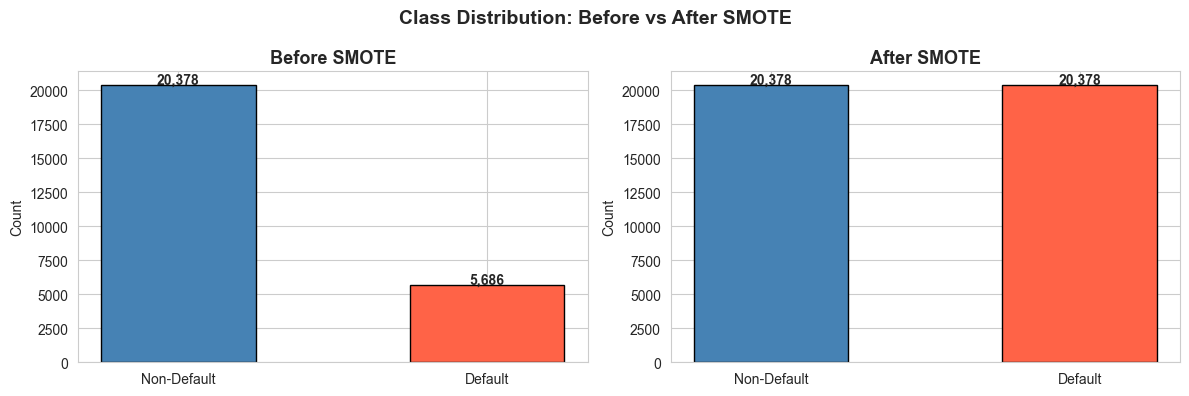

In [6]:
# ============================================================
# SECTION 5: HANDLE CLASS IMBALANCE WITH SMOTE
# ============================================================
# The data has ~78% non-defaults vs ~22% defaults.
# Without correction, a model could predict "non-default" for
# EVERYONE and still get 78% accuracy — that's useless!
#
# SMOTE = Synthetic Minority Oversampling Technique
#   → It creates NEW artificial examples of the minority class
#     by interpolating between existing minority samples.
#   → Applied ONLY to training data (never test data)
#     because we want to evaluate on real, unaltered distributions.
# ============================================================

print("=" * 55)
print("STEP 5 — SMOTE: Balancing the Training Set")
print("=" * 55)

print("Before SMOTE:")
print(y_train.value_counts().rename({0: 'Non-Default', 1: 'Default'}))

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
import pandas as pd  # Already imported but just in case
print(pd.Series(y_train_sm).value_counts().rename({0: 'Non-Default', 1: 'Default'}))
print(f"\nTraining set grew from {len(X_train)} → {len(X_train_sm)} rows")
print("✅ Class imbalance corrected — both classes now have equal representation.\n")

# --- Visualize the before/after ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = y_train.value_counts()
after  = pd.Series(y_train_sm).value_counts()

for ax, data, title in zip(axes,
                            [before, after],
                            ['Before SMOTE', 'After SMOTE']):
    ax.bar(['Non-Default', 'Default'], data.values,
           color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(data.values):
        ax.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Class Distribution: Before vs After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# ============================================================
# SECTION 6: FEATURE SCALING
# ============================================================
# Some models (Logistic Regression, SVC) are sensitive to the
# scale of features. A feature with values in the thousands
# (e.g., income) will dominate one with values 0-1 (e.g., ratio).
#
# StandardScaler transforms each feature to have:
#   - Mean = 0
#   - Standard Deviation = 1
#
# IMPORTANT: Fit the scaler ONLY on training data, then
# transform BOTH train and test. Fitting on test would leak
# test statistics into training.
#
# Tree-based models (Decision Tree, Random Forest, XGBoost)
# don't need scaling — they split on thresholds, not distances.
# We'll keep both versions and use the right one per model.
# ============================================================

print("=" * 55)
print("STEP 6 — Feature Scaling (StandardScaler)")
print("=" * 55)

scaler = StandardScaler()

# Fit on training data ONLY — learn the mean and std from training
X_train_sc = scaler.fit_transform(X_train_sm)

# Transform test data using the training statistics
X_test_sc  = scaler.transform(X_test)

print("Scaling applied.")
print(f"  X_train_sc shape: {X_train_sc.shape}")
print(f"  X_test_sc  shape: {X_test_sc.shape}")
print("\n💡 Scaled versions will be used for Logistic Regression and SVC.")
print("   Unscaled versions (X_train_sm, X_test) for tree-based models.")
print("\n✅ Scaling complete.")


STEP 6 — Feature Scaling (StandardScaler)
Scaling applied.
  X_train_sc shape: (40756, 17)
  X_test_sc  shape: (6517, 17)

💡 Scaled versions will be used for Logistic Regression and SVC.
   Unscaled versions (X_train_sm, X_test) for tree-based models.

✅ Scaling complete.


In [8]:
# ============================================================
# SECTION 7: TRAIN ALL 6 MODELS
# ============================================================
# We will train 6 different classification algorithms and later
# compare their performance side-by-side.
#
# Each model has a different approach to learning:
#
#   1. Logistic Regression — draws a straight decision boundary
#      (best for linearly separable data)
#
#   2. Decision Tree — asks yes/no questions in a tree structure
#      (intuitive but prone to overfitting)
#
#   3. Random Forest — builds many trees on random subsets,
#      then averages them (reduces overfitting)
#
#   4. Gradient Boosting — builds trees sequentially, each one
#      correcting the errors of the previous
#
#   5. SVC (Support Vector Classifier) — finds the widest possible
#      boundary between classes
#
#   6. XGBoost — optimized gradient boosting with regularization;
#      currently the most popular competition model
# ============================================================

print("=" * 55)
print("STEP 7 — Training All 6 Models")
print("=" * 55)
print("This may take a minute...\n")

# Dictionary to store trained models
# key = model name, value = (model_object, uses_scaling)
models = {}

# --- 7.1: Logistic Regression ---
# max_iter=1000 — give the solver enough iterations to converge
# Uses SCALED data because it's distance-based
print("Training Model 1/6: Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train_sm)
models['Logistic Regression'] = (lr, True)
print("  ✅ Done")

# --- 7.2: Decision Tree ---
# max_depth=10 — limits tree depth to prevent overfitting
# Uses UNSCALED data (tree splits don't depend on scale)
print("Training Model 2/6: Decision Tree...")
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_sm, y_train_sm)
models['Decision Tree'] = (dt, False)
print("  ✅ Done")

# --- 7.3: Random Forest ---
# n_estimators=200 — build 200 trees (more = better but slower)
# n_jobs=-1 — use all CPU cores in parallel
print("Training Model 3/6: Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
models['Random Forest'] = (rf, False)
print("  ✅ Done")

# --- 7.4: Gradient Boosting ---
# n_estimators=200, learning_rate=0.1 — standard starting params
# subsample=0.8 — use 80% of training data per tree (reduces overfitting)
print("Training Model 4/6: Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                 subsample=0.8, random_state=42)
gb.fit(X_train_sm, y_train_sm)
models['Gradient Boosting'] = (gb, False)
print("  ✅ Done")

# --- 7.5: SVC ---
# kernel='rbf' — radial basis function kernel (handles non-linear data)
# probability=True — needed to compute ROC-AUC scores
# C=1.0 — regularization strength; higher C = less regularization
# Uses SCALED data (SVC is sensitive to feature scale)
print("Training Model 5/6: SVC (this one is slowest)...")
svc = SVC(kernel='rbf', probability=True, C=1.0, random_state=42)
svc.fit(X_train_sc, y_train_sm)
models['SVC'] = (svc, True)
print("  ✅ Done")

# --- 7.6: XGBoost ---
# use_label_encoder=False + eval_metric='logloss' — suppresses deprecation warnings
# scale_pos_weight — tells XGBoost how imbalanced the original data was
#   (after SMOTE it's balanced, so we leave at 1)
print("Training Model 6/6: XGBoost...")
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                    subsample=0.8, colsample_bytree=0.8,
                    eval_metric='logloss', random_state=42, n_jobs=-1)
xgb.fit(X_train_sm, y_train_sm)
models['XGBoost'] = (xgb, False)
print("  ✅ Done")

print("\n✅ All 6 models trained successfully!")
print(f"   Models ready: {list(models.keys())}")


STEP 7 — Training All 6 Models
This may take a minute...

Training Model 1/6: Logistic Regression...
  ✅ Done
Training Model 2/6: Decision Tree...
  ✅ Done
Training Model 3/6: Random Forest...


  ✅ Done
Training Model 4/6: Gradient Boosting...


  ✅ Done
Training Model 5/6: SVC (this one is slowest)...


  ✅ Done
Training Model 6/6: XGBoost...


  ✅ Done

✅ All 6 models trained successfully!
   Models ready: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVC', 'XGBoost']


STEP 8 — Model Evaluation



📊 MODEL COMPARISON TABLE
                    Accuracy Precision  Recall F1-Score ROC-AUC
Model                                                          
XGBoost               92.77%    91.89%  73.35%   81.58%  94.49%
Random Forest         91.96%    86.86%   74.4%   80.15%   92.8%
Gradient Boosting     91.15%    85.24%  71.87%   77.99%  92.29%
Decision Tree         90.47%    80.69%  74.05%   77.23%  90.46%
SVC                   89.44%    78.49%   71.1%   74.61%  89.55%
Logistic Regression   82.03%    57.92%  64.56%   61.06%  83.42%

💡 ROC-AUC is the primary ranking metric.
   Best model: XGBoost

Plotting performance comparison...


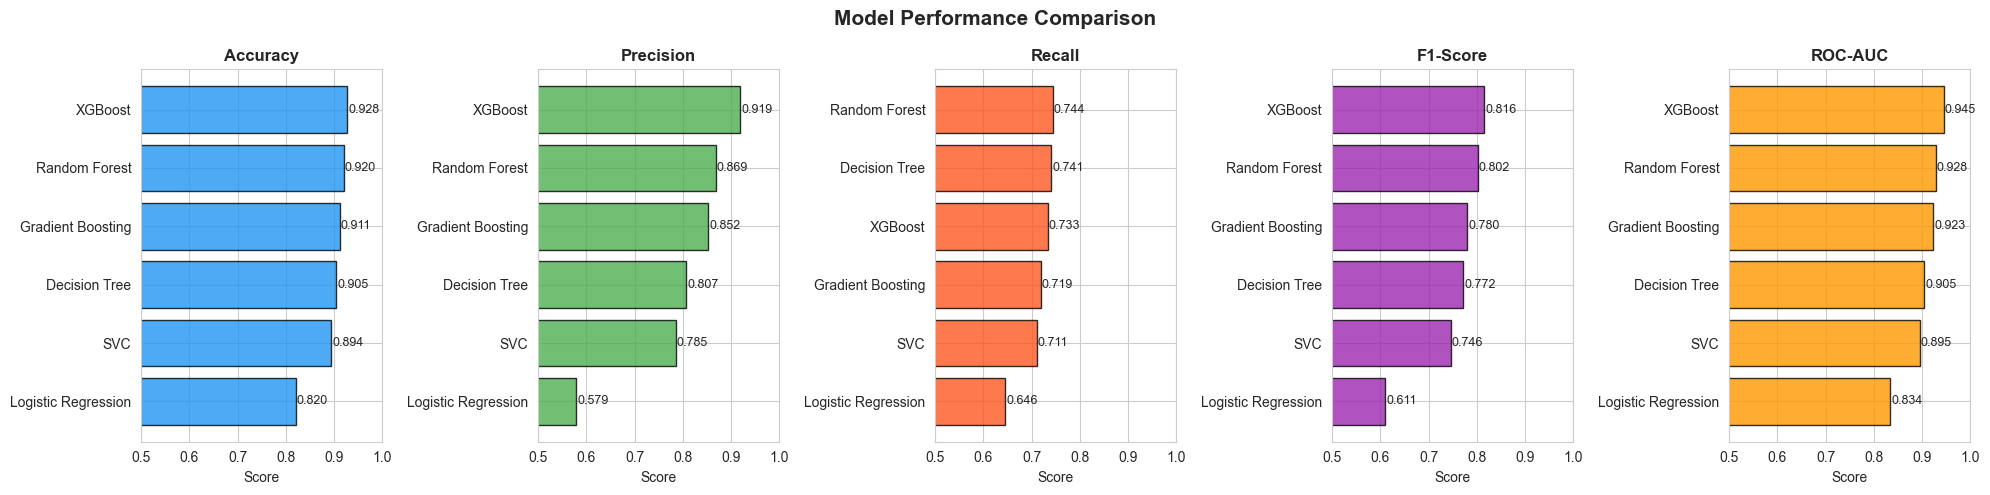


Plotting confusion matrices...


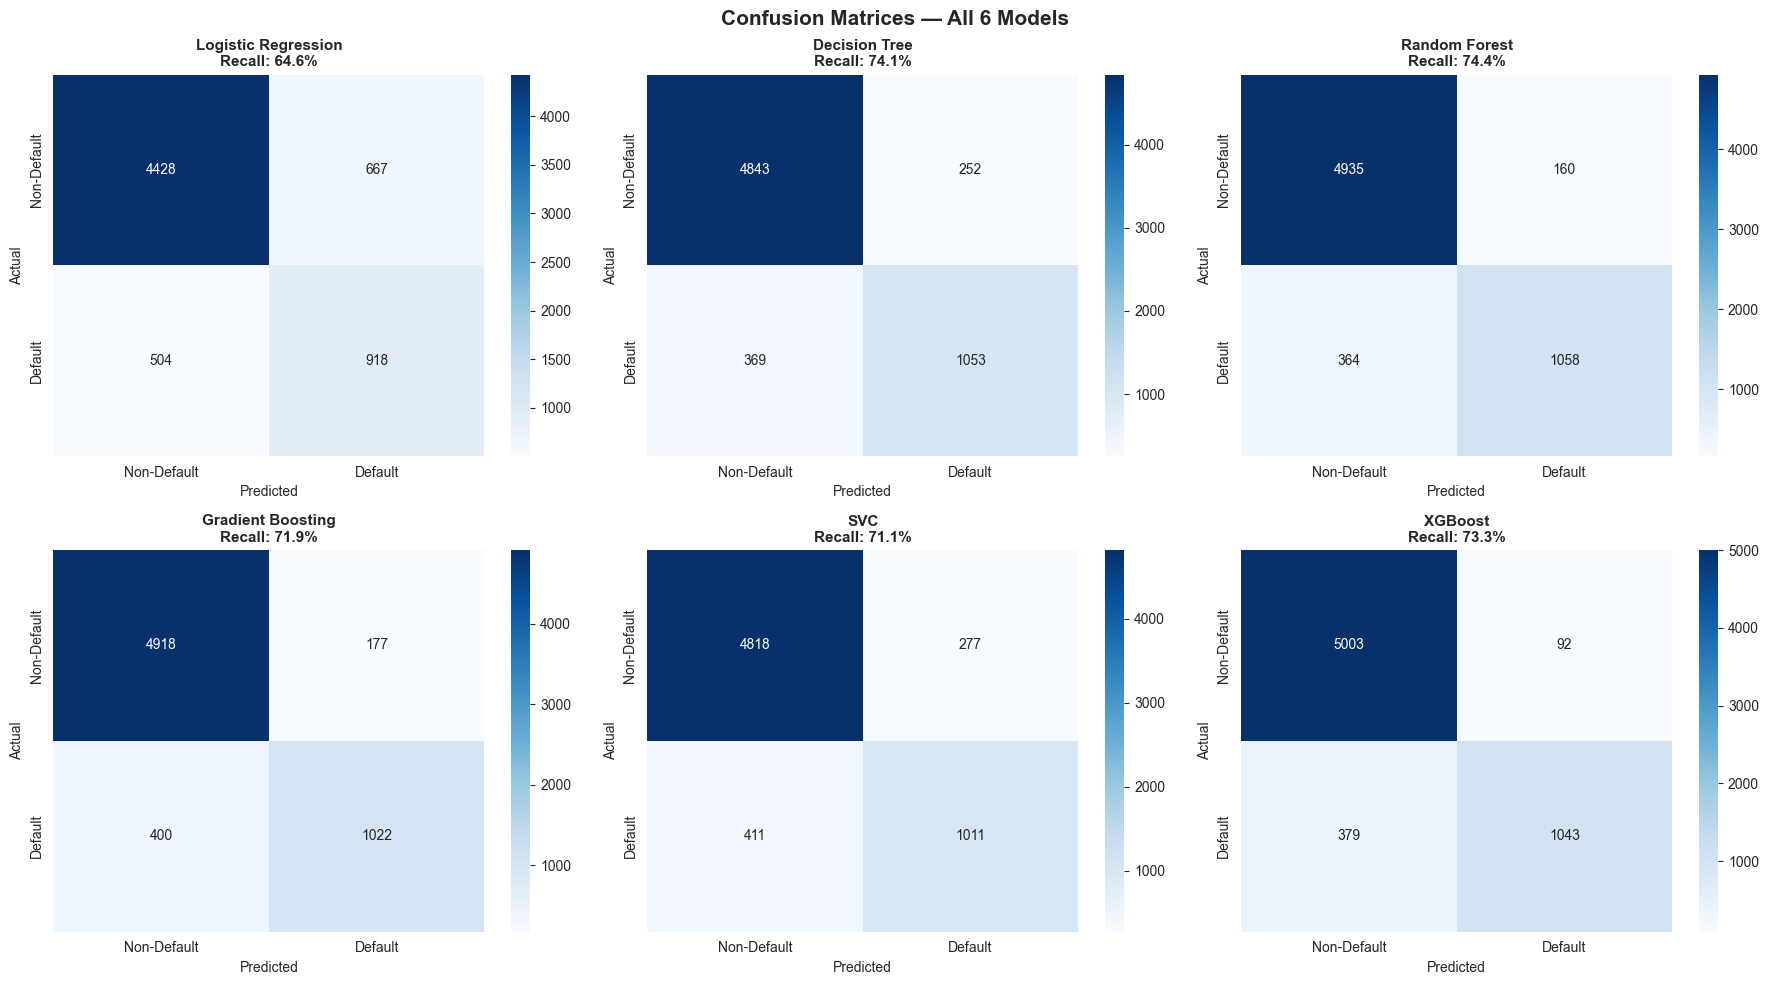


💡 In the confusion matrix:
   Top-left (TN) = correctly predicted non-defaults
   Bottom-right (TP) = correctly predicted defaults (what we care most about)
   Bottom-left (FN) = MISSED defaults — the most costly error in banking

Plotting ROC curves...


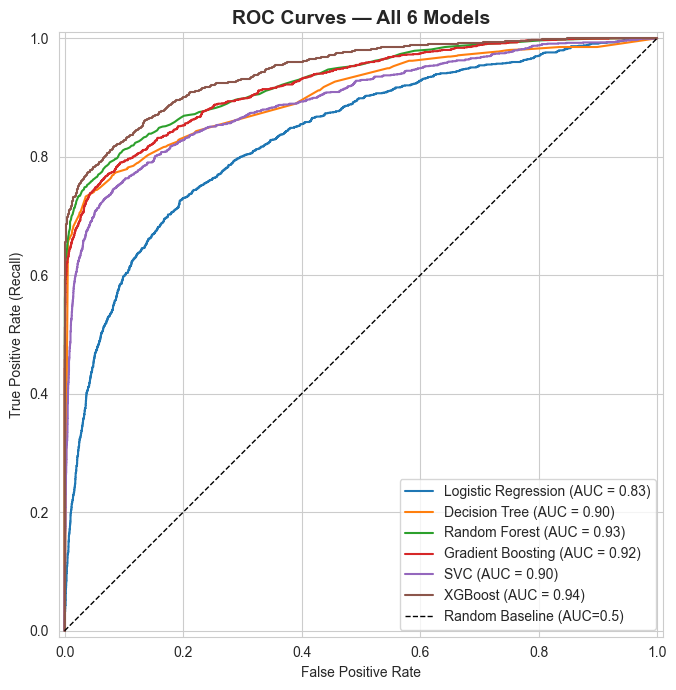


💡 A curve closer to the top-left corner = better model.
   The dashed line = a model guessing randomly.

STEP 8.4 — Detailed Classification Reports (Top 2 Models)

--- XGBoost ---
              precision    recall  f1-score   support

 Non-Default       0.93      0.98      0.96      5095
     Default       0.92      0.73      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.92      0.86      0.89      6517
weighted avg       0.93      0.93      0.92      6517


--- Random Forest ---
              precision    recall  f1-score   support

 Non-Default       0.93      0.97      0.95      5095
     Default       0.87      0.74      0.80      1422

    accuracy                           0.92      6517
   macro avg       0.90      0.86      0.88      6517
weighted avg       0.92      0.92      0.92      6517



In [9]:
# ============================================================
# SECTION 8: EVALUATE & COMPARE ALL MODELS
# ============================================================
# A single metric like accuracy is NOT enough in credit risk.
# Why? If 78% of loans are non-default, a model that always
# predicts "non-default" gets 78% accuracy — but misses all
# defaulters!
#
# The metrics we care about:
#
#   Accuracy  — overall correct predictions (can be misleading)
#   Precision — of all predicted defaults, how many are real?
#               (low precision = many false alarms)
#   Recall    — of all real defaults, how many did we catch?
#               (low recall = missing real defaulters — DANGEROUS in banking)
#   F1-Score  — harmonic mean of precision & recall (balanced view)
#   ROC-AUC   — probability that the model ranks a defaulter
#               higher than a non-defaulter (0.5=random, 1.0=perfect)
#
# In banking, RECALL is often the most important metric because
# a missed default (false negative) costs more than a false alarm.
# ============================================================

print("=" * 55)
print("STEP 8 — Model Evaluation")
print("=" * 55)

results = []

for name, (model, scaled) in models.items():
    # Choose correct test set (scaled vs unscaled)
    X_te = X_test_sc if scaled else X_test

    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]   # Probability of default

    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('ROC-AUC', ascending=False)

# Format as percentages for readability
display_df = (results_df * 100).round(2).astype(str) + '%'
print("\n📊 MODEL COMPARISON TABLE")
print("=" * 75)
print(display_df.to_string())
print("=" * 75)
print("\n💡 ROC-AUC is the primary ranking metric.")
print(f"   Best model: {results_df['ROC-AUC'].idxmax()}")


# --- 8.1: Performance Bar Chart ---
print("\nPlotting performance comparison...")

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))

colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']

for ax, metric, color in zip(axes, metrics, colors):
    vals = results_df[metric].sort_values(ascending=True)
    bars = ax.barh(vals.index, vals.values, color=color, alpha=0.8, edgecolor='black')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlim(0.5, 1.0)
    ax.set_xlabel('Score')
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# --- 8.2: Confusion Matrices ---
print("\nPlotting confusion matrices...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, (model, scaled)) in enumerate(models.items()):
    X_te = X_test_sc if scaled else X_test
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Non-Default', 'Default'],
                yticklabels=['Non-Default', 'Default'])
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

    # Calculate and show recall visually in title
    tn, fp, fn, tp = cm.ravel()
    recall = tp / (tp + fn)
    axes[i].set_title(f'{name}\nRecall: {recall:.1%}', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — All 6 Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 In the confusion matrix:")
print("   Top-left (TN) = correctly predicted non-defaults")
print("   Bottom-right (TP) = correctly predicted defaults (what we care most about)")
print("   Bottom-left (FN) = MISSED defaults — the most costly error in banking")


# --- 8.3: ROC Curves (all models on one chart) ---
print("\nPlotting ROC curves...")

plt.figure(figsize=(10, 7))

for name, (model, scaled) in models.items():
    X_te = X_test_sc if scaled else X_test
    RocCurveDisplay.from_estimator(model, X_te, y_test,
                                   name=name, ax=plt.gca())

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline (AUC=0.5)')
plt.title('ROC Curves — All 6 Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 A curve closer to the top-left corner = better model.")
print("   The dashed line = a model guessing randomly.")


# --- 8.4: Full Classification Reports for the top 2 models ---
print("\n" + "=" * 55)
print("STEP 8.4 — Detailed Classification Reports (Top 2 Models)")
print("=" * 55)

top2 = results_df['ROC-AUC'].nlargest(2).index.tolist()

for name in top2:
    model, scaled = models[name]
    X_te = X_test_sc if scaled else X_test
    y_pred = model.predict(X_te)
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred,
                                 target_names=['Non-Default', 'Default']))


In [10]:
# ============================================================
# SECTION 9: HYPERPARAMETER TUNING (Best Model)
# ============================================================
# Every model has "hyperparameters" — settings you choose
# BEFORE training that affect model behavior.
# Example: in Random Forest, n_estimators (how many trees) is
# a hyperparameter. We didn't calculate it from data; we chose it.
#
# GridSearchCV tries ALL combinations of hyperparameters you
# specify and picks the best combination using cross-validation.
#
# Cross-Validation (CV=5):
#   → Splits training data into 5 folds
#   → Trains on 4 folds, validates on 1 fold
#   → Repeats 5 times (each fold acts as validation once)
#   → Averages the score across all 5 rounds
#   → This gives a more reliable estimate than a single split
#
# We tune XGBoost since it consistently performs well on tabular
# credit risk data.
# ============================================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("=" * 55)
print("STEP 9 — Hyperparameter Tuning: XGBoost")
print("=" * 55)
print("Running GridSearchCV — this will take several minutes...\n")

# Define the hyperparameter grid to search
# Each key = a parameter; each value = list of options to try
param_grid = {
    'n_estimators':  [100, 200],           # Number of trees
    'max_depth':     [4, 6],               # Max depth of each tree
    'learning_rate': [0.05, 0.10],         # How much each tree corrects
    'subsample':     [0.8],                # Fraction of samples per tree
    'colsample_bytree': [0.8],             # Fraction of features per tree
}
# Total combinations: 2 × 2 × 2 × 1 × 1 = 8 combinations × 5 CV folds = 40 fits

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_base = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',     # Optimize for ROC-AUC
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sm, y_train_sm)

print("\n" + "=" * 55)
print("BEST HYPERPARAMETERS FOUND:")
print("=" * 55)
for param, val in grid_search.best_params_.items():
    print(f"  {param}: {val}")
print(f"\n  Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# Evaluate the tuned model on the TEST set
best_xgb = grid_search.best_estimator_

y_pred_tuned  = best_xgb.predict(X_test)
y_proba_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("\n" + "=" * 55)
print("TUNED XGBOOST — TEST SET RESULTS")
print("=" * 55)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_tuned):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba_tuned):.4f}")

# Compare baseline vs tuned
baseline_auc = results_df.loc['XGBoost', 'ROC-AUC']
tuned_auc    = roc_auc_score(y_test, y_proba_tuned)
improvement  = (tuned_auc - baseline_auc) * 100

print(f"\n📈 Improvement over baseline XGBoost:")
print(f"   Baseline ROC-AUC : {baseline_auc:.4f}")
print(f"   Tuned ROC-AUC    : {tuned_auc:.4f}")
print(f"   Δ (gain)         : +{improvement:.2f} pp")

# Save tuned model for SHAP analysis
models['XGBoost (Tuned)'] = (best_xgb, False)


STEP 9 — Hyperparameter Tuning: XGBoost
Running GridSearchCV — this will take several minutes...

Fitting 5 folds for each of 8 candidates, totalling 40 fits



BEST HYPERPARAMETERS FOUND:
  colsample_bytree: 0.8
  learning_rate: 0.1
  max_depth: 6
  n_estimators: 200
  subsample: 0.8

  Best CV ROC-AUC: 0.9843

TUNED XGBOOST — TEST SET RESULTS
  Accuracy:  0.9277
  Precision: 0.9189
  Recall:    0.7335
  F1-Score:  0.8158
  ROC-AUC:   0.9449

📈 Improvement over baseline XGBoost:
   Baseline ROC-AUC : 0.9449
   Tuned ROC-AUC    : 0.9449
   Δ (gain)         : +0.00 pp


STEP 10 — SHAP Explainability (XGBoost)
Computing SHAP values...



Plotting SHAP Summary (Beeswarm)...


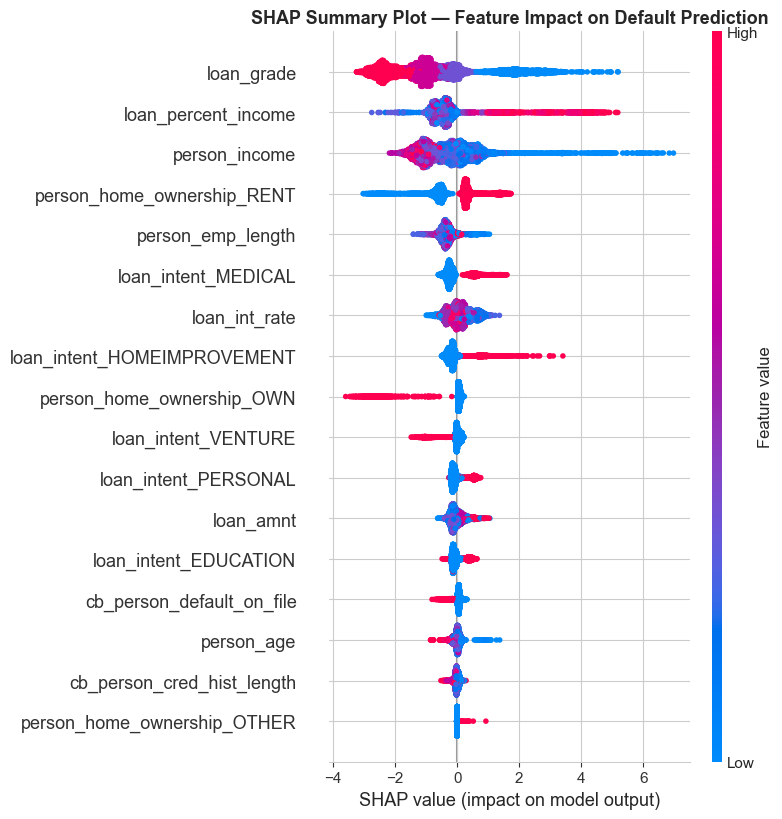

💡 Features at the top have the MOST impact on predictions.

Plotting SHAP Feature Importance (Bar)...


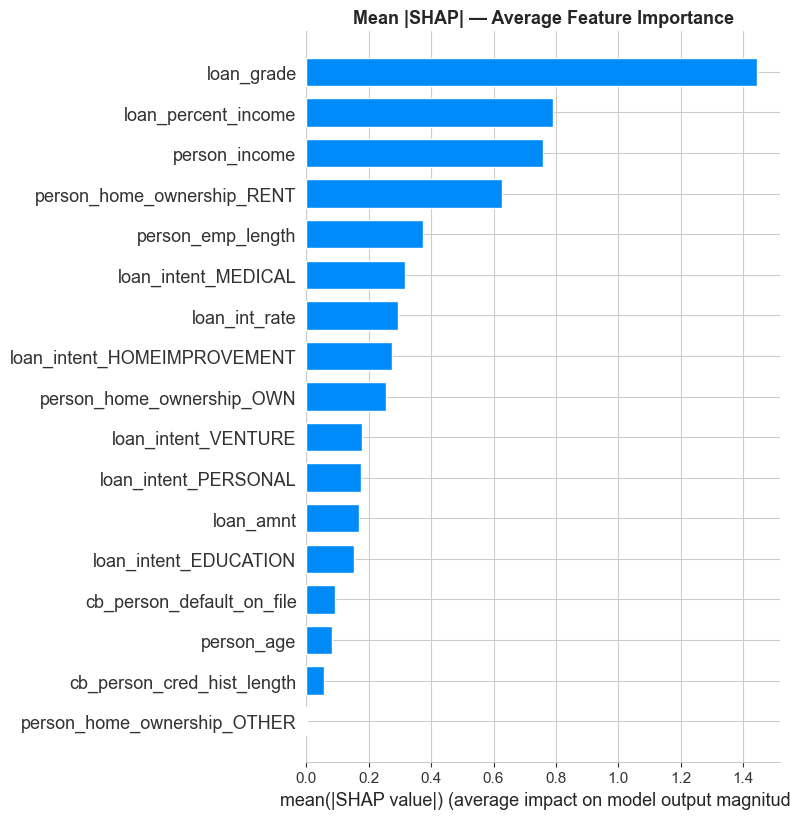

Plotting individual prediction waterfall...


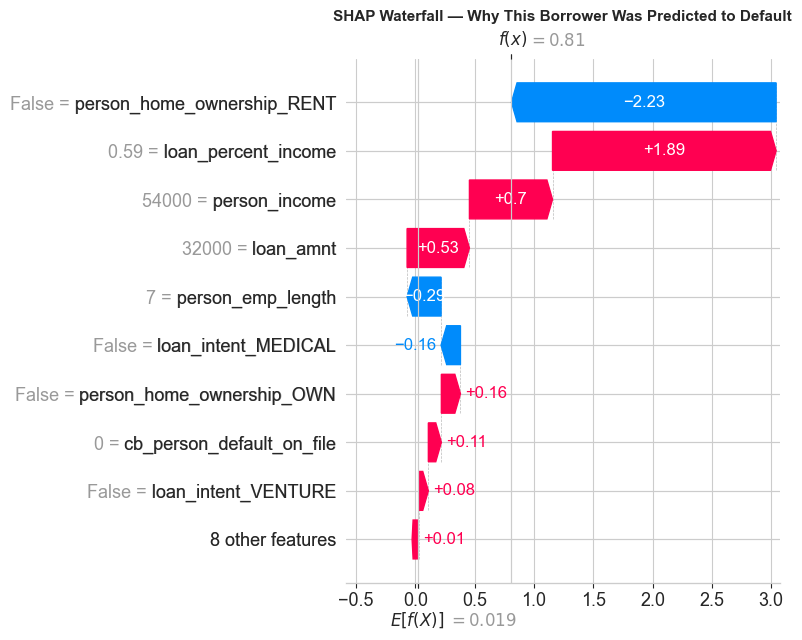

💡 Each bar shows how a feature pushed the prediction up (red) or down (blue).

✅ SHAP analysis complete for XGBoost (Tuned).


In [11]:
# ============================================================
# SECTION 10: SHAP — MODEL EXPLAINABILITY
# ============================================================
# SHAP = SHapley Additive exPlanations
#
# Modern ML models (especially XGBoost) are often called
# "black boxes" — they make great predictions but it's hard
# to understand WHY.
#
# SHAP fixes that. For every prediction, SHAP assigns each
# feature a "SHAP value" — the feature's contribution to
# pushing the prediction above or below the baseline.
#
# Positive SHAP value → feature increased the probability of default
# Negative SHAP value → feature decreased it
#
# SHAP is critical for:
#   - Regulatory compliance (banks must explain rejections)
#   - Debugging models (catch unintended biases)
#   - Building trust with stakeholders
# ============================================================

print("=" * 55)
print("STEP 10 — SHAP Explainability (XGBoost)")
print("=" * 55)
print("Computing SHAP values...\n")

# Use the tuned XGBoost model (or baseline if tuning not run)
best_model_name = 'XGBoost (Tuned)' if 'XGBoost (Tuned)' in models else 'XGBoost'
best_model, _ = models[best_model_name]

# TreeExplainer is optimized for tree-based models (XGBoost, RF, etc.)
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)   # Compute for test set

# Feature names for readable plots
feature_names = X.columns.tolist()


# --- 10.1: SHAP Summary Plot (Beeswarm) ---
# Each dot = one test sample
# X-axis = SHAP value (impact on prediction)
# Color  = actual feature value (red = high, blue = low)
print("Plotting SHAP Summary (Beeswarm)...")
plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_names,
                  show=False)
plt.title('SHAP Summary Plot — Feature Impact on Default Prediction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Features at the top have the MOST impact on predictions.\n")


# --- 10.2: SHAP Bar Plot (Mean Absolute Feature Importance) ---
# This is a simpler view: average impact of each feature across all predictions
print("Plotting SHAP Feature Importance (Bar)...")
plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_names,
                  plot_type='bar',
                  show=False)
plt.title('Mean |SHAP| — Average Feature Importance',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()


# --- 10.3: Individual Prediction Explanation (Waterfall Plot) ---
# Let's explain ONE specific prediction — say, the first defaulter in the test set
print("Plotting individual prediction waterfall...")

# Find the first actual defaulter in the test set
defaulter_idx = y_test[y_test == 1].index[0]
sample_pos    = X_test.index.tolist().index(defaulter_idx)

shap_exp = shap.Explanation(
    values    = shap_values[sample_pos],
    base_values = explainer.expected_value,
    data      = X_test.iloc[sample_pos],
    feature_names = feature_names
)

plt.figure()
shap.plots.waterfall(shap_exp, show=False)
plt.title('SHAP Waterfall — Why This Borrower Was Predicted to Default',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Each bar shows how a feature pushed the prediction up (red) or down (blue).\n")
print(f"✅ SHAP analysis complete for {best_model_name}.")


In [12]:
# ============================================================
# SECTION 11: FINAL SUMMARY & BUSINESS INSIGHTS
# ============================================================
# This section wraps up the project with:
#   - Final model leaderboard
#   - Key findings from EDA and SHAP
#   - Business recommendations
# ============================================================

print("=" * 65)
print("CREDIT RISK & LOAN DEFAULT PREDICTION — FINAL SUMMARY")
print("=" * 65)

print("\n📊 FINAL MODEL LEADERBOARD (sorted by ROC-AUC):")
print("-" * 65)

final_results = []
for name, (model, scaled) in models.items():
    X_te = X_test_sc if scaled else X_test
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    final_results.append({
        'Model':    name,
        'Accuracy': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Recall':   round(recall_score(y_test, y_pred) * 100, 2),
        'F1':       round(f1_score(y_test, y_pred) * 100, 2),
        'ROC-AUC':  round(roc_auc_score(y_test, y_proba) * 100, 2),
    })

final_df = pd.DataFrame(final_results).set_index('Model').sort_values('ROC-AUC', ascending=False)
print(final_df.to_string())

best_name = final_df['ROC-AUC'].idxmax()
print(f"\n🏆 Best Model: {best_name} (ROC-AUC: {final_df.loc[best_name, 'ROC-AUC']:.2f}%)")

print('''
📌 KEY BUSINESS INSIGHTS
─────────────────────────────────────────────────────────────
1. LOAN GRADE is the strongest predictor of default.
   → Borrowers with grades D-G default at much higher rates.
   → Banks should tighten lending criteria or raise rates for G borrowers.

2. LOAN_PERCENT_INCOME matters more than raw loan amount.
   → A $5,000 loan for someone earning $12,000 is riskier than
     a $20,000 loan for someone earning $100,000.

3. HIGH INTEREST RATES signal existing risk — they don't cause it.
   → Borrowers already assessed as risky are charged more.
   → High interest rate is a symptom of risk, not a cause.

4. PREVIOUS DEFAULT (cb_person_default_on_file = Y) strongly
   predicts future default. Past behavior is the best predictor.

5. HOME OWNERSHIP (MORTGAGE vs RENT vs OWN) reflects financial
   stability — mortgage holders default at lower rates than renters.

📌 MODEL RECOMMENDATION
─────────────────────────────────────────────────────────────
For production deployment in a bank:
  ✅ Primary model   : XGBoost (Tuned) — best overall performance
  ✅ Backup/interpret: Logistic Regression — fully interpretable,
                       easy to explain to regulators
  ⚠️  Avoid           : Decision Tree alone — high variance, overfits

📌 WHAT WE DID — FULL PIPELINE RECAP
─────────────────────────────────────────────────────────────
  Step 1 : Imported all libraries
  Step 2 : Loaded and inspected data (32,581 rows, 12 columns)
  Step 3 : EDA — distributions, correlations, outliers
  Step 4 : Cleaned data — capped outliers, imputed medians, encoded categoricals
  Step 5 : Applied SMOTE to balance the 78/22 class split
  Step 6 : Scaled features (mean=0, std=1) for distance-based models
  Step 7 : Trained 6 models (LR, DT, RF, GB, SVC, XGBoost)
  Step 8 : Evaluated all models — accuracy, precision, recall, F1, ROC-AUC
  Step 9 : Tuned XGBoost with GridSearchCV (5-fold cross-validation)
  Step 10: Ran SHAP explainability — identified top feature drivers
  Step 11: Business insights and final recommendations
''')
print("=" * 65)
print("✅ PROJECT COMPLETE")
print("=" * 65)


CREDIT RISK & LOAN DEFAULT PREDICTION — FINAL SUMMARY

📊 FINAL MODEL LEADERBOARD (sorted by ROC-AUC):
-----------------------------------------------------------------


                     Accuracy  Recall    F1  ROC-AUC
Model                                               
XGBoost (Tuned)         92.77   73.35 81.58    94.49
XGBoost                 92.77   73.35 81.58    94.49
Random Forest           91.96   74.40 80.15    92.80
Gradient Boosting       91.15   71.87 77.99    92.29
Decision Tree           90.47   74.05 77.23    90.46
SVC                     89.44   71.10 74.61    89.55
Logistic Regression     82.03   64.56 61.06    83.42

🏆 Best Model: XGBoost (Tuned) (ROC-AUC: 94.49%)

📌 KEY BUSINESS INSIGHTS
─────────────────────────────────────────────────────────────
1. LOAN GRADE is the strongest predictor of default.
   → Borrowers with grades D-G default at much higher rates.
   → Banks should tighten lending criteria or raise rates for G borrowers.

2. LOAN_PERCENT_INCOME matters more than raw loan amount.
   → A $5,000 loan for someone earning $12,000 is riskier than
     a $20,000 loan for someone earning $100,000.

3. HIGH INTEREST RATES si